<a href="https://colab.research.google.com/github/viniciusarnom/estudo_dirigido/blob/main/Arquivo%20de%20Importa%C3%A7%C3%A3o%20Inicial%20com%20Magnitude%20e%20Espectro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lendo e concatenando arquivos...
Total de amostras concatenadas: 15000000
Arquivo consolidado salvo como: WiFi_Day_1_browning_concat.bin
Calculando FFT... (Isso pode levar uns instantes devido ao tamanho do arquivo)


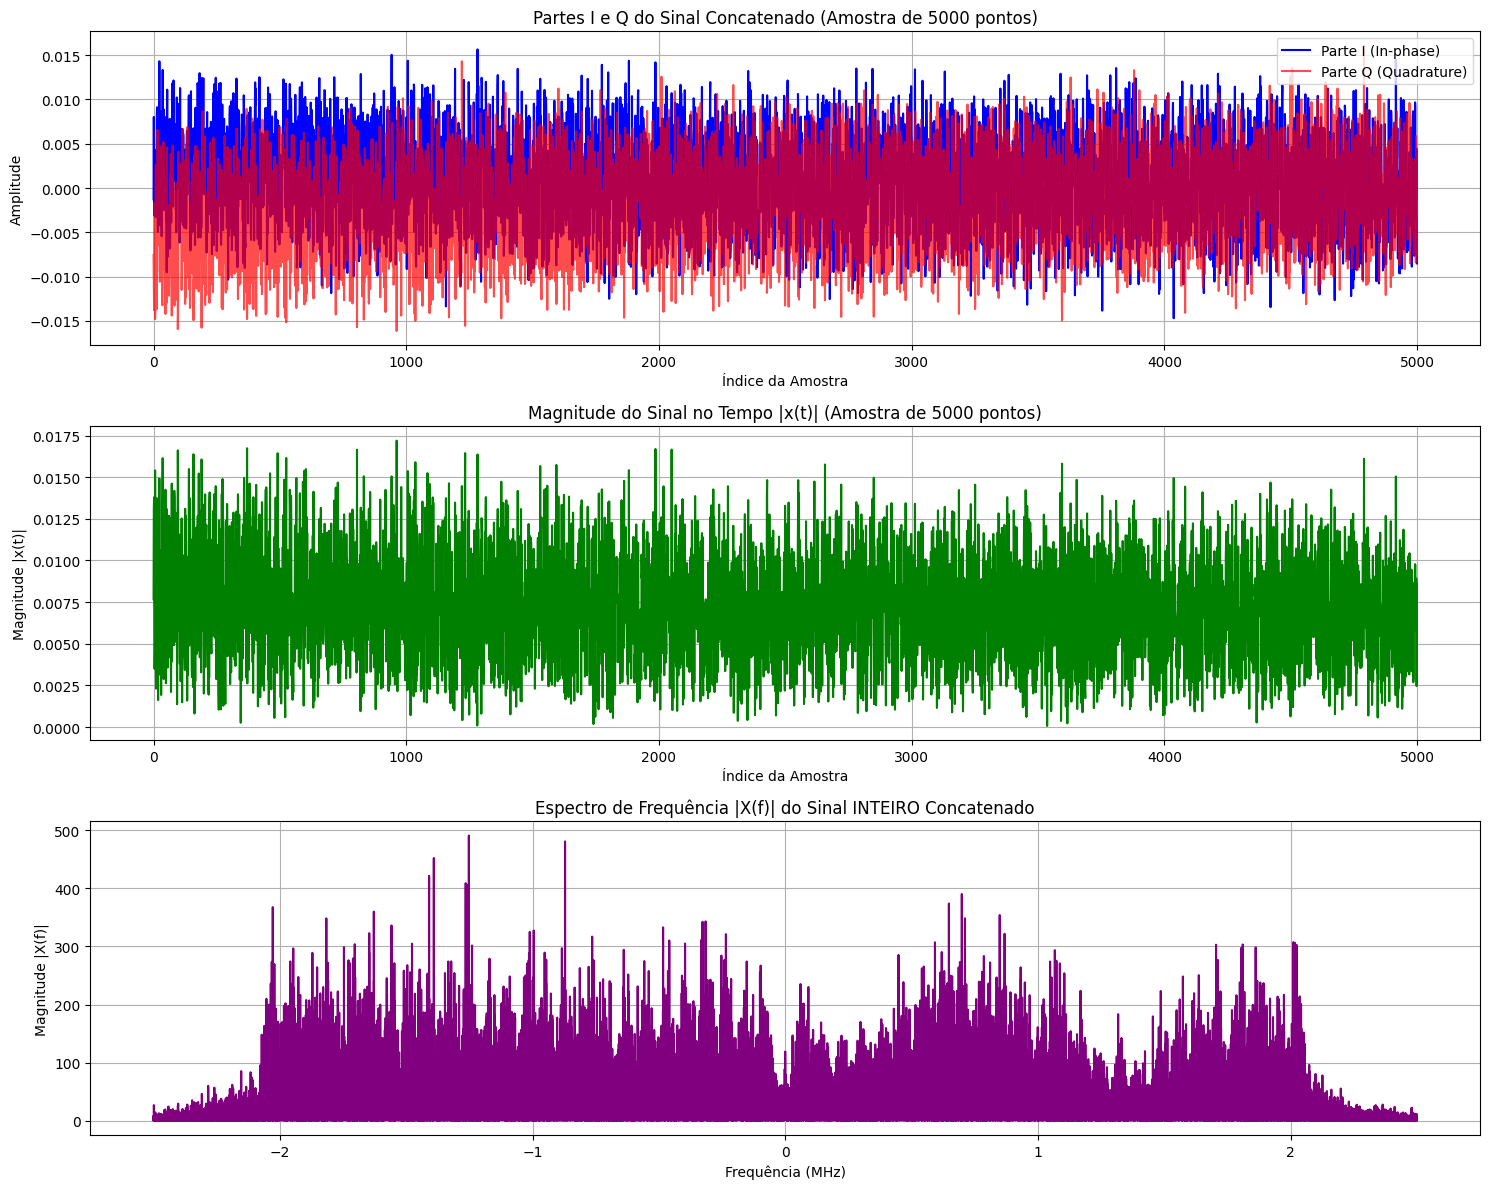

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir os arquivos que queremos ler
files = [
    'WiFi_Day_1_browning_s1.bin',
    'WiFi_Day_1_browning_s2.bin',
    'WiFi_Day_1_browning_s3.bin',
    'WiFi_Day_1_browning_s4.bin',
    'WiFi_Day_1_browning_s5.bin'
]

# 2. Ler todos os arquivos e guardar em uma lista
print("Lendo e concatenando arquivos...")
data_list = []
for f in files:
    # Lê usando o tipo complex64 para já ter a forma I + jQ
    data_list.append(np.fromfile(f, dtype=np.complex64))

# 3. Concatenar os arrays em um único bloco de sinal
concat_data = np.concatenate(data_list)
print(f"Total de amostras concatenadas: {len(concat_data)}")

# 4. Salvar o dado concatenado num novo arquivo '.bin'
output_filename = 'WiFi_Day_1_browning_concat.bin'
concat_data.tofile(output_filename)
print(f"Arquivo consolidado salvo como: {output_filename}")

# --- Cálculos para o Gráfico ---

# Recorte de amostras (5.000) para os gráficos de tempo não ficarem muito densos
n_plot = 5000
plot_data_time = concat_data[:n_plot]

I = np.real(plot_data_time)
Q = np.imag(plot_data_time)
magnitude_time = np.abs(plot_data_time)

# 5. Calcular a Transformada de Fourier (FFT) no Sinal CONCATENADO INTEIRO
print("Calculando FFT... (Isso pode levar uns instantes devido ao tamanho do arquivo)")
fs = 5e6 # Frequência de 5 MHz baseada nos seus JSONs
X_f = np.fft.fft(concat_data)
X_f_shifted = np.fft.fftshift(X_f)
spectrum_magnitude = np.abs(X_f_shifted)
freqs = np.fft.fftshift(np.fft.fftfreq(len(concat_data), 1/fs))

# 6. Criar as Figuras e Plotar
plt.figure(figsize=(15, 12))

# Subplot 1: I e Q
plt.subplot(3, 1, 1)
plt.plot(I, label='Parte I (In-phase)', color='blue')
plt.plot(Q, label='Parte Q (Quadrature)', color='red', alpha=0.7)
plt.title(f'Partes I e Q do Sinal Concatenado (Amostra de {n_plot} pontos)')
plt.xlabel('Índice da Amostra')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

# Subplot 2: Magnitude (Tempo)
plt.subplot(3, 1, 2)
plt.plot(magnitude_time, color='green')
plt.title(f'Magnitude do Sinal no Tempo |x(t)| (Amostra de {n_plot} pontos)')
plt.xlabel('Índice da Amostra')
plt.ylabel('Magnitude |x(t)|')
plt.grid(True)

# Subplot 3: Espectro (Frequência)
plt.subplot(3, 1, 3)
# Decimation: pegamos um "pulo" de dados para não plotar 15 milhões de pontinhos no gráfico
step = max(1, len(freqs) // 100000)
plt.plot(freqs[::step] / 1e6, spectrum_magnitude[::step], color='purple')
plt.title('Espectro de Frequência |X(f)| do Sinal INTEIRO Concatenado')
plt.xlabel('Frequência (MHz)')
plt.ylabel('Magnitude |X(f)|')
plt.grid(True)

plt.tight_layout()
plt.show() # Na sua máquina, mostrará o gráfico direto na tela